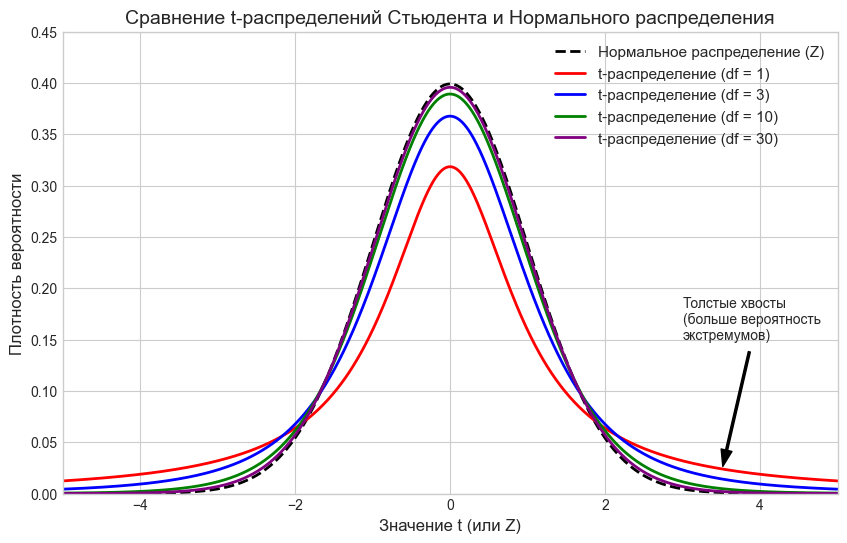

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Настройка стиля графика (делает его красивым)
plt.style.use('seaborn-v0_8-whitegrid')

# Создаем массив значений по оси X от -5 до 5
x = np.linspace(-5, 5, 1000)

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Строим стандартное нормальное распределение (для сравнения)
# Среднее = 0, стандартное отклонение = 1
y_norm = norm.pdf(x, loc=0, scale=1)
ax.plot(x, y_norm, 'k--', linewidth=2, label='Нормальное распределение (Z)')

# 2. Строим t-распределения с РАЗНЫМИ числами степеней свободы (df)
degrees_of_freedom = [1, 3, 10, 30]
colors = ['red', 'blue', 'green', 'purple']

for df, color in zip(degrees_of_freedom, colors):
    y_t = t.pdf(x, df=df) # pdf - функция плотности вероятности
    ax.plot(x, y_t, color=color, linewidth=2, label=f't-распределение (df = {df})')

# Настройки графика
ax.set_title('Сравнение t-распределений Стьюдента и Нормального распределения', fontsize=14)
ax.set_xlabel('Значение t (или Z)', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.45)

# Добавляем аннотацию про "толстые хвосты"
ax.annotate('Толстые хвосты\n(больше вероятность\nэкстремумов)', 
            xy=(3.5, 0.02), xytext=(3.0, 0.15),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10)

# Показываем график
plt.show()

C:\Users\Никита\AppData\Local\Temp\ipykernel_26836\625169161.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=groups_ind, y=data_ind, palette="Set2", width=0.4)


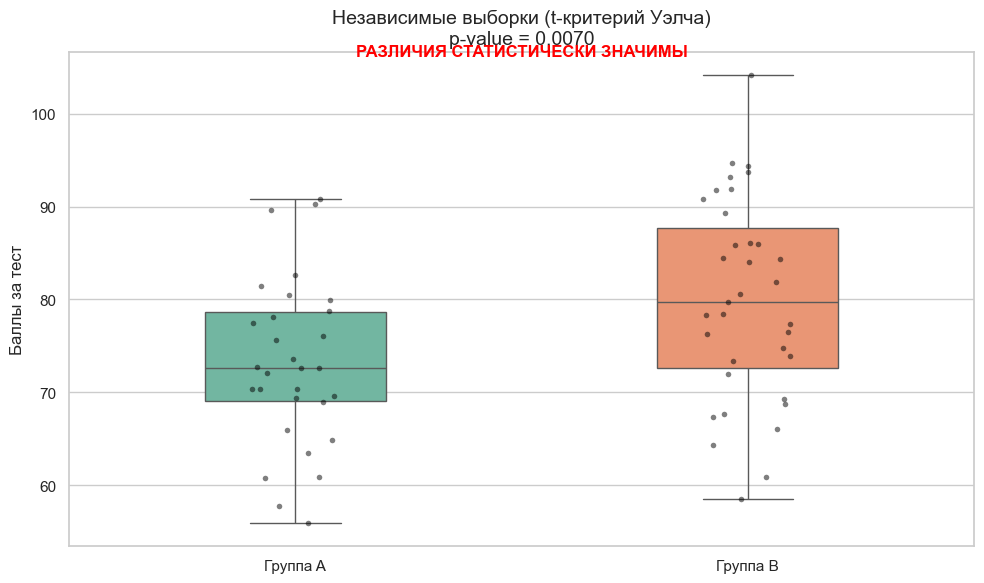

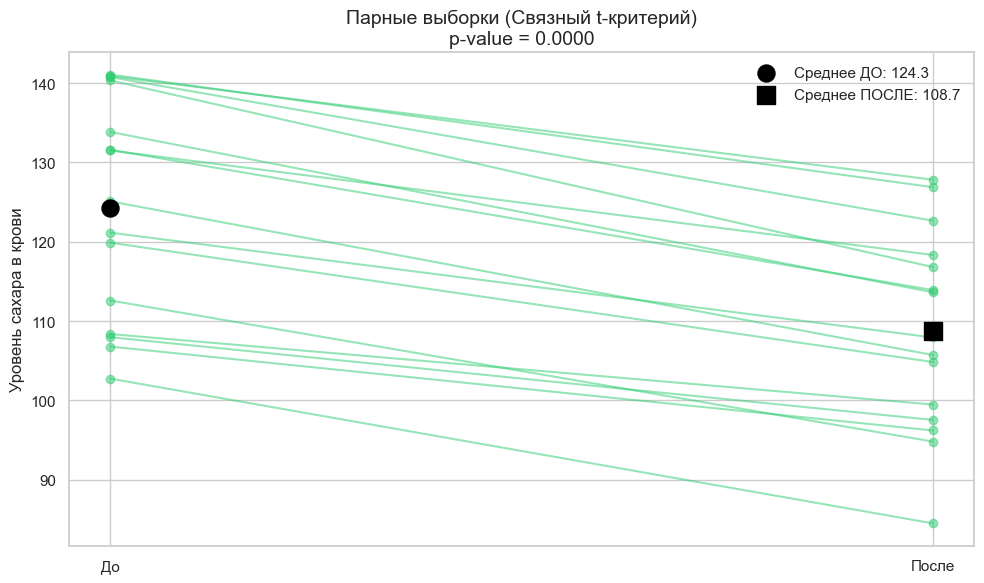

--- Анализ независимых выборок ---
t-статистика: -2.789, p-value: 0.0070

--- Анализ парных выборок ---
t-статистика: 14.615, p-value: 0.0000


In [2]:
import seaborn as sns
from scipy.stats import ttest_ind, ttest_rel

# Настройка стиля для красивых графиков
sns.set_theme(style="whitegrid")
np.random.seed(42) # Для воспроизводимости результатов

# ========================================================
# ГРАФИК 1: НЕЗАВИСИМЫЕ ВЫБОРКИ (Критерий Уэлча)
# ========================================================
# Допустим, сравниваем баллы за тест двух разных групп студентов
group_A = np.random.normal(loc=75, scale=10, size=30) # Среднее 75, отклонение 10
group_B = np.random.normal(loc=82, scale=12, size=35) # Среднее 82, отклонение 12

# Проводим тест (equal_var=False означает, что используем Уэлча)
t_stat_ind, p_val_ind = ttest_ind(group_A, group_B, equal_var=False)

# Подготовка данных для seaborn
data_ind = np.concatenate([group_A, group_B])
groups_ind = ['Группа A'] * len(group_A) + ['Группа B'] * len(group_B)

plt.figure(figsize=(10, 6))
sns.boxplot(x=groups_ind, y=data_ind, palette="Set2", width=0.4)
sns.stripplot(x=groups_ind, y=data_ind, color="black", alpha=0.5, size=4)

# Добавляем текст с результатами
plt.title(f'Независимые выборки (t-критерий Уэлча)\np-value = {p_val_ind:.4f}', fontsize=14)
plt.ylabel('Баллы за тест', fontsize=12)
plt.xlabel('')

# Логика вывода
if p_val_ind < 0.05:
    plt.text(0.5, max(data_ind)+2, "РАЗЛИЧИЯ СТАТИСТИЧЕСКИ ЗНАЧИМЫ", 
             ha='center', fontsize=12, color='red', weight='bold')
else:
    plt.text(0.5, max(data_ind)+2, "Статистически значимых различий нет", 
             ha='center', fontsize=12, color='green', weight='bold')

plt.tight_layout()
plt.show()


# ========================================================
# ГРАФИК 2: СВЯЗАННЫЕ (ПАРНЫЕ) ВЫБОРКИ
# ========================================================
# Допустим, измеряем уровень сахара в крови ДО и ПОСЛЕ приема препарата
n_paired = 15
before = np.random.normal(loc=120, scale=15, size=n_paired)
# После препарата сахар падает, но добавляем разброс
after = before - np.random.normal(loc=15, scale=5, size=n_paired) 

# Проводим парный тест
t_stat_pair, p_val_pair = ttest_rel(before, after)

plt.figure(figsize=(10, 6))

# Рисуем линии для каждого пациента
for i in range(n_paired):
    # Если сахар упал - линия синяя (зеленая), если вырос - красная
    color = '#2ecc71' if before[i] > after[i] else '#e74c3c'
    plt.plot(['До', 'После'], [before[i], after[i]], color=color, alpha=0.5, marker='o', markersize=6)

# Отмечаем средние значения
plt.scatter(['До'], [np.mean(before)], color='black', s=150, zorder=5, label=f'Среднее ДО: {np.mean(before):.1f}')
plt.scatter(['После'], [np.mean(after)], color='black', s=150, marker='s', zorder=5, label=f'Среднее ПОСЛЕ: {np.mean(after):.1f}')

plt.title(f'Парные выборки (Связный t-критерий)\np-value = {p_val_pair:.4f}', fontsize=14)
plt.ylabel('Уровень сахара в крови', fontsize=12)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("--- Анализ независимых выборок ---")
print(f"t-статистика: {t_stat_ind:.3f}, p-value: {p_val_ind:.4f}")
print("\n--- Анализ парных выборок ---")
print(f"t-статистика: {t_stat_pair:.3f}, p-value: {p_val_pair:.4f}")